4200
700
700
tensor(0.0029) tensor(0.0060)
<class 'torchvision.tv_tensors._image.Image'>
<class 'torchvision.tv_tensors._image.Image'>


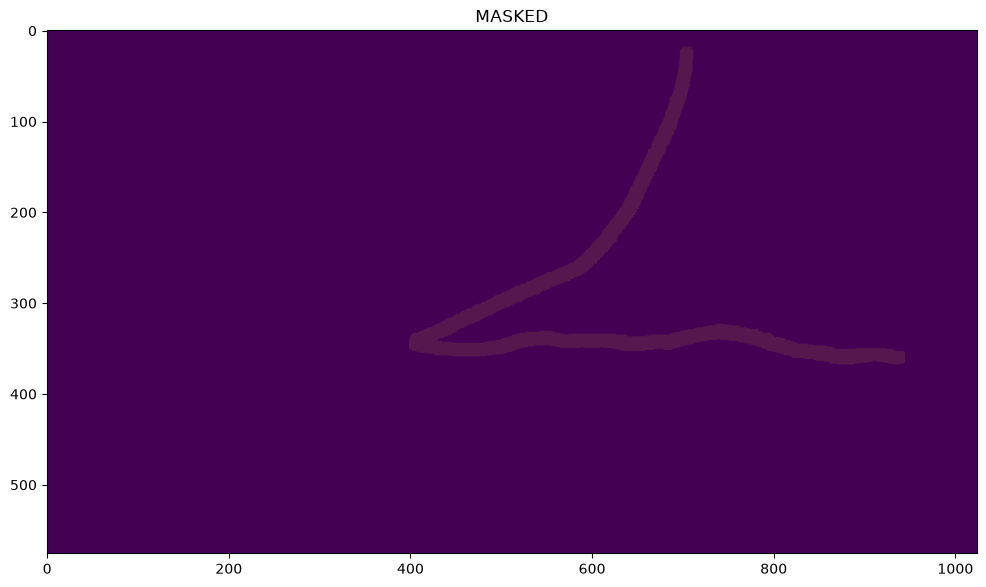

epoch 1 / 15
train loss = 0.001970452967600609
vali loss = 0.12694856240635827
epoch 2 / 15
train loss = 0.00020440865234953515
vali loss = 0.0004509367347401123
epoch 3 / 15
train loss = 0.00019636879527793827
vali loss = 0.00024279142824179005
epoch 4 / 15
train loss = 0.00017716756568402265
vali loss = 0.00040253157550025555
epoch 5 / 15
train loss = 0.000182943063377552
vali loss = 0.00047155165174488155
epoch 6 / 15
train loss = 0.00016525041603350848
vali loss = 0.00034703548105123144
epoch 7 / 15
train loss = 0.00016100043029913623
vali loss = 0.00032351184996687587
epoch 8 / 15
train loss = 0.00015786314471016055
vali loss = 0.00034394777183132687
epoch 9 / 15
train loss = 0.00015749711633188018
vali loss = 0.000342974238308324
epoch 10 / 15
train loss = 0.0001560538873720278
vali loss = 0.000295660990689482
epoch 11 / 15
train loss = 0.00015354549434730953
vali loss = 0.0003192743523478774
epoch 12 / 15
train loss = 0.00015241540333021518
vali loss = 0.0003261721056852756
epoc

In [1]:
import cygnet, torch, os
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from torchvision.ops import sigmoid_focal_loss

# paths
train_path = "/home/frx/dataset/image_dataset/train"
vali_path = "/home/frx/dataset/image_dataset/vali"
test_path = "/home/frx/dataset/image_dataset/test"

# folders:
input_path = "input"
mask_path = "mask"
mask_exp2_path = "mask_exp2"
mask_exp4_path = "mask_exp4"

# change this
target_path = mask_exp4_path

input_train_path = os.path.join(train_path, input_path)
target_train_path = os.path.join(train_path, target_path)

input_vali_path = os.path.join(vali_path, input_path)
target_vali_path = os.path.join(vali_path, target_path)

input_test_path = os.path.join(test_path, input_path)
target_test_path = os.path.join(test_path, target_path)

train_dset = cygnet.CygnoSet(input_train_path, target_train_path)
print(len(train_dset))
vali_dset = cygnet.CygnoSet(input_vali_path, target_vali_path)
print(len(vali_dset))
test_dset = cygnet.CygnoSet(input_test_path, target_test_path)
print(len(test_dset))

image, mask = train_dset[1]

print(image.min(), image.max())
print(type(mask))
print(type(image))

cygnet.debug_plot(image.cpu().squeeze(), mask.cpu().squeeze())

train_dloader = DataLoader(train_dset, batch_size=32, shuffle=True, num_workers=4, drop_last=True)
vali_dloader = DataLoader(vali_dset, batch_size=32, shuffle=True, num_workers=2, drop_last=True)
test_dloader = DataLoader(test_dset, batch_size=32, shuffle=True, num_workers=2, drop_last=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

net = cygnet.Net(16).to(device)
opt = torch.optim.AdamW(net.parameters(), lr=1e-2, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.StepLR(opt, 5, gamma=0.5, last_epoch=-1)

num_epochs = 15
train_loss_history = []
vali_loss_history = []

for epoch in range(num_epochs):
	print(f"epoch {epoch+1} / {num_epochs}")
	
	net.train()
	train_loss = 0
	c = 0
	for imgs, masks in train_dloader:
		c += 1
		imgs  = imgs.to(device, non_blocking=True)
		masks = masks.to(device, non_blocking=True)
		opt.zero_grad(set_to_none=True)
		
		preds = net(imgs)

		loss = sigmoid_focal_loss(preds, masks, reduction="mean")
		loss.backward()
		opt.step()
		train_loss += loss.item()
	
	train_loss /= c
	train_loss_history.append(train_loss)
	print(f"train loss = {train_loss}")
	
	net.eval()
	vali_loss = 0
	c = 0
	with torch.inference_mode():
		for imgs, masks in vali_dloader:
			c += 1
			imgs  = imgs.to(device, non_blocking=True)
			masks = masks.to(device, non_blocking=True)

			preds = net(imgs)

			vloss = sigmoid_focal_loss(preds, masks, reduction="mean")
			vali_loss += vloss.item()
		vali_loss /= c
		vali_loss_history.append(vali_loss)
		print(f"vali loss = {vali_loss}")
	
	scheduler.step()

[0.001970452967600609, 0.00020440865234953515, 0.00019636879527793827, 0.00017716756568402265, 0.000182943063377552, 0.00016525041603350848, 0.00016100043029913623, 0.00015786314471016055, 0.00015749711633188018, 0.0001560538873720278, 0.00015354549434730953, 0.00015241540333021518, 0.00015291425473130493, 0.000150627565522632, 0.00015030075211205896]


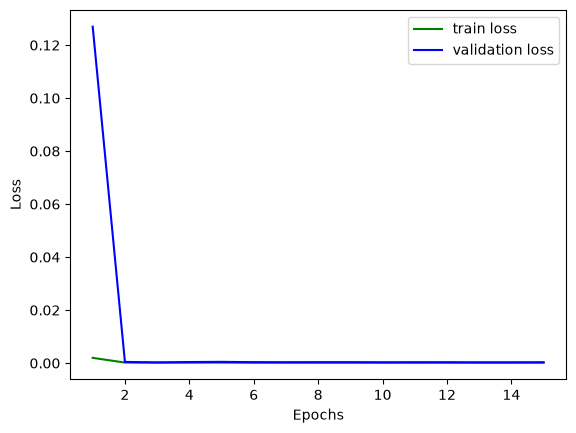

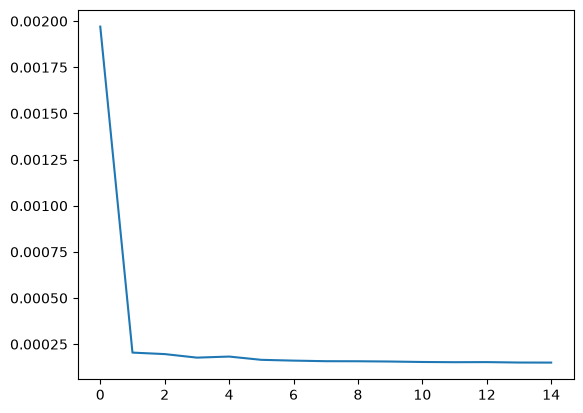

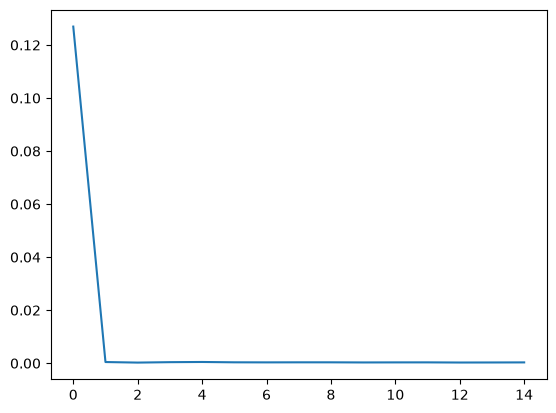

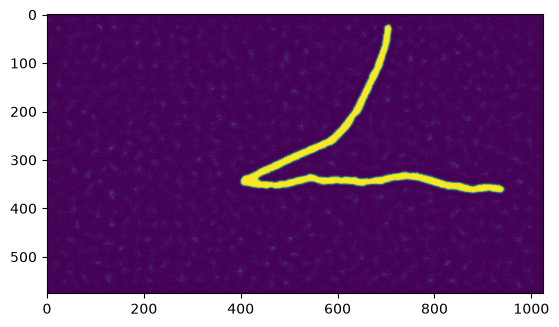

tensor(0.5000, device='cuda:0') tensor(7.9513e-05, device='cuda:0')


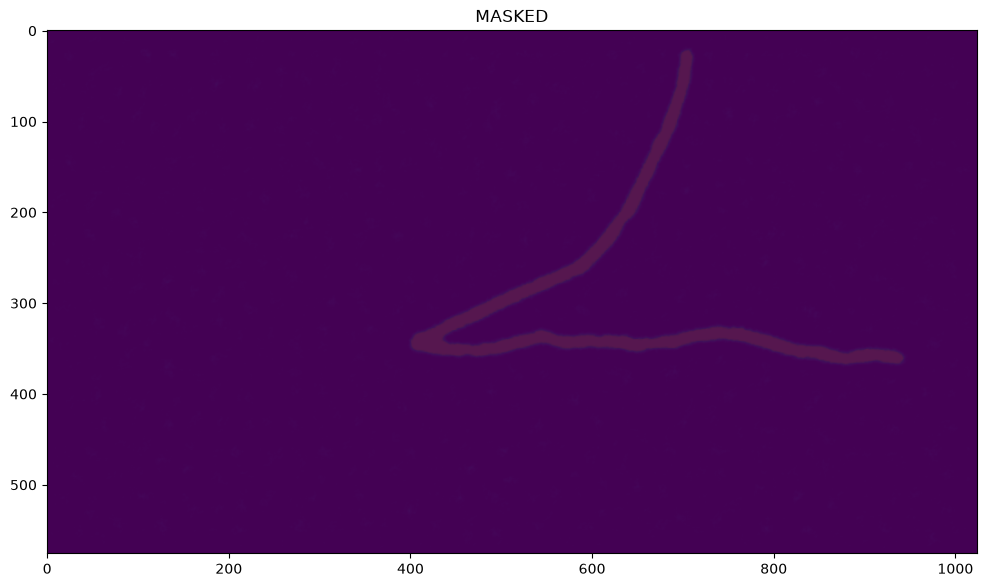

In [2]:
xt = [x for x in range(len(train_loss_history))]
xv = [x for x in range(len(vali_loss_history))]

print(train_loss_history)

net.eval()

plt.plot(range(1,len(train_loss_history)+1), train_loss_history, color='green', linestyle='-', label='train loss')
plt.plot(range(1,len(vali_loss_history)+1), vali_loss_history, color='blue', linestyle='-', label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.figure()
plt.plot(xt, train_loss_history)
plt.show()

plt.figure()
plt.plot(xv, vali_loss_history)
plt.show()
net.eval()

with torch.inference_mode():
	pred = net(image.unsqueeze(0).to(device))
pred = torch.sigmoid(pred)

plt.figure()
plt.imshow(pred.cpu().squeeze())
plt.show()

print(pred.max(), pred.min())
cygnet.debug_plot(image.cpu().squeeze(), pred.cpu().squeeze())

tensor(0., device='cuda:0') tensor(-9.5018, device='cuda:0')
tensor(0.5000, device='cuda:0') tensor(7.4714e-05, device='cuda:0')


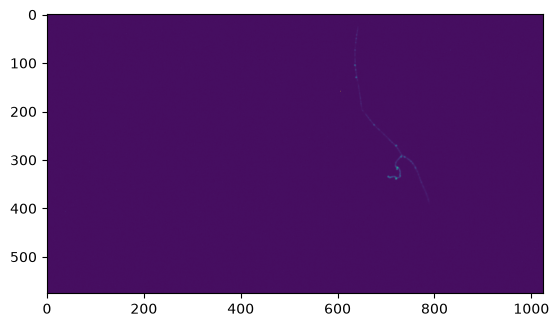

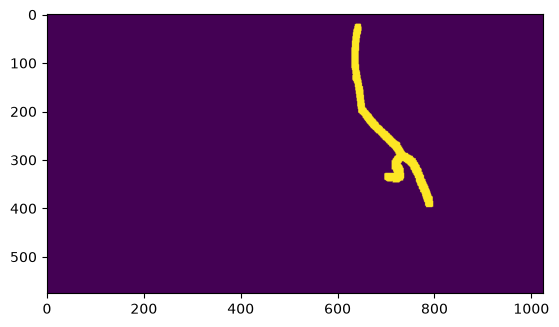

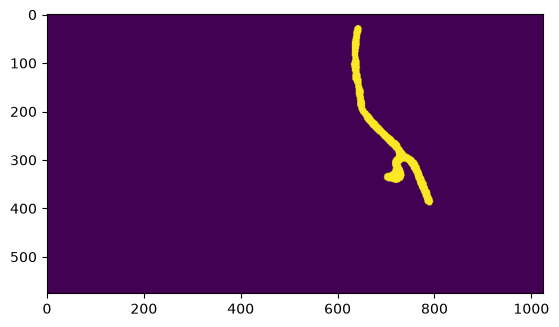

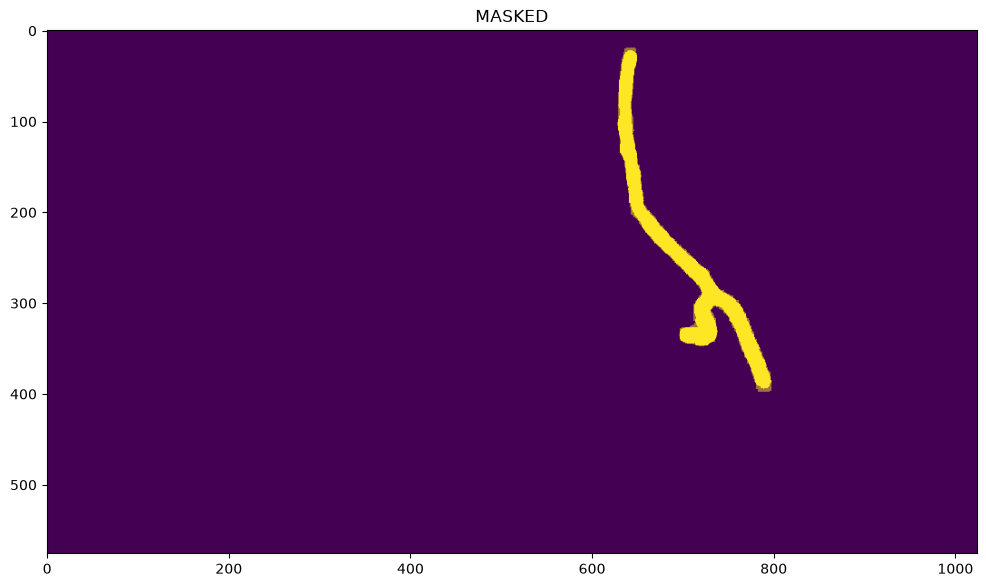

focal loss : 0.6234
recall     : 0.9145
precision  : 0.9845
compression: 1.3804%


In [3]:
def quickplot(img):
	plt.figure()
	plt.imshow(img.cpu().squeeze())
	plt.show()

def evaluate(pred, mask, threshold=0.2):
	pred_prob = torch.sigmoid(pred)
	pred_mask = pred_prob > threshold
	true_mask = mask > 0.5

	tp = (pred_mask & true_mask).sum().item()
	fp = (pred_mask & ~true_mask).sum().item()
	fn = (~pred_mask & true_mask).sum().item()

	recall    = tp / (tp + fn + 1e-8)
	precision = tp / (tp + fp + 1e-8)
	compression = pred_mask.float().mean().item()
	loss = sigmoid_focal_loss(mask, pred, reduction="mean").item()

	print(f"focal loss : {loss:.4f}")
	print(f"recall     : {recall:.4f}")
	print(f"precision  : {precision:.4f}")
	print(f"compression: {compression:.4%}")

image, mask = test_dset[31]
net.eval()

with torch.inference_mode():
	pred = net(image.unsqueeze(0).to(device))
spred = torch.sigmoid(pred)
sspred = (spred > 0.2).float()

print(pred.max(), pred.min())
print(spred.max(), spred.min())

quickplot(image)
quickplot(mask)
quickplot(sspred)

cygnet.debug_plot(mask.squeeze(), sspred.cpu().squeeze(), 0.5, None, None)

evaluate(pred.cpu().squeeze(), mask.cpu().squeeze())



In [4]:
save = True

if save:
	torch.save({'model' : net,
		'epoch': epoch+1,
		'model_state_dict': net.state_dict(),
		'optimizer_state_dict': opt.state_dict(),
		'loss': sigmoid_focal_loss,
		}, 'saved_models/best_model_base16_drop.pt')